# Aditya-L1 MAG L2 Data Characterization

This notebook characterizes the Aditya-L1 Magnetometer (MAG) Level-2
dataset before large-scale analysis. It examines the dataset structure,
metadata, temporal coverage, data quality, magnetic-field components,
and basic statistical properties of the interplanetary magnetic field.

## Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
DATA_DIR = Path("../data/raw/L2")
files = sorted(DATA_DIR.glob("*.nc"))

print(f"Number of L2 files: {len(files)}")

Number of L2 files: 91


In [3]:
print(f"Number of files: {len(files)}")
print(f"First file: {files[0].name}")
print(f"Last file: {files[-1].name}")

Number of files: 91
First file: L2_AL1_MAG_20260410_V00.nc
Last file: L2_AL1_MAG_20260803_V00.nc


In [4]:
file = files[0]

ds = xr.open_dataset(
    file,
    engine="h5netcdf"
)

print(f"File: {file.name}")
ds

File: L2_AL1_MAG_20260410_V00.nc


<xarray.Dataset> Size: 726kB
Dimensions:                (utc_time: 8640, Bx: 8640, By: 8640, Bz: 8640)
Dimensions without coordinates: utc_time, Bx, By, Bz
Data variables: (12/20)
    time                   (utc_time) float64 69kB ...
    Bx_gse                 (Bx) float32 35kB ...
    By_gse                 (By) float32 35kB ...
    Bz_gse                 (Bz) float32 35kB ...
    Bx_gsm                 (Bx) float32 35kB ...
    By_gsm                 (By) float32 35kB ...
    ...                     ...
    x_gse                  (Bx) float32 35kB ...
    y_gse                  (By) float32 35kB ...
    z_gse                  (Bz) float32 35kB ...
    x_gsm                  (Bx) float32 35kB ...
    y_gsm                  (By) float32 35kB ...
    z_gsm                  (Bz) float32 35kB ...
Attributes: (12/20)
    title:                     Aditya-L1 Magnetometer data
    summary:                   Magnetometer onboard Aditya-L1 provides in-sit...
    keywords:                  Magnetic field, IMF, Solar wind, in-situ, magn...
    Conventions:               ACDD-1.3
    source:                    Aditya-L1 Magnetometer L1 data
    processing_level:          Level 2
    ...                        ...
    instrument:                Magnetometer
    publisher_name:            ISSDC
    publisher_url:             www.issdc.gov.in,pradan.issdc.gov.in/al1
    Fill_value:                -9999.0
    Fill_value_description:    Denotes either missing data or invalid data
    missing_data_percentage:   21.98

## Dataset Metadata

In [5]:
print(ds.attrs)

{'title': 'Aditya-L1 Magnetometer data', 'summary': 'Magnetometer onboard Aditya-L1 provides in-situ measurements of interplanetary\n        magnetic field(IMF). The payload consists of two identical tri-axial fluxgate magnetometers placed on a boom at 3m and 6m from the spacecraft.\n        The sensor located at 6m is named as MAG1, while the sensor at 3m is labelled MAG2. At Level1,the dataset consists of output from both \n        MAG1 and MAG2 at a cadence of 128ms. These datasets contain the IMF, and a slow varying component of spacecraft field and sensor offsets.\n        Using the dataset of both the sensors, estimation of IMF by removal of the slow-varying component is done at Level2. The Level2 dataset \n        is provided at a minimum cadence of 10 seconds in different standard frames like GSE, GSM, and RTN. The science-ready data level from \n        the MAGNETOMETER payload is thus Level2.Users who intend to use Level1 dataset, ought to consult the instrument team for furt

In [6]:
for name, variable in ds.variables.items():
    print(
        f"{name:30} "
        f"dims={variable.dims} "
        f"shape={variable.shape} "
        f"dtype={variable.dtype}"
    )

time                           dims=('utc_time',) shape=(8640,) dtype=float64
Bx_gse                         dims=('Bx',) shape=(8640,) dtype=float32
By_gse                         dims=('By',) shape=(8640,) dtype=float32
Bz_gse                         dims=('Bz',) shape=(8640,) dtype=float32
Bx_gsm                         dims=('Bx',) shape=(8640,) dtype=float32
By_gsm                         dims=('By',) shape=(8640,) dtype=float32
Bz_gsm                         dims=('Bz',) shape=(8640,) dtype=float32
Bx_gse_error                   dims=('Bx',) shape=(8640,) dtype=float32
By_gse_error                   dims=('By',) shape=(8640,) dtype=float32
Bz_gse_error                   dims=('Bz',) shape=(8640,) dtype=float32
Bx_gsm_error                   dims=('Bx',) shape=(8640,) dtype=float32
By_gsm_error                   dims=('By',) shape=(8640,) dtype=float32
Bz_gsm_error                   dims=('Bz',) shape=(8640,) dtype=float32
Quality_flag_10s_data          dims=('utc_time',) shape=(8

In [7]:
variables = [
    "Bx_gse",
    "By_gse",
    "Bz_gse",
    "Bx_gsm",
    "By_gsm",
    "Bz_gsm",
    "Quality_flag_10s_data",
]

for name in variables:
    print(f"\n{'=' * 60}")
    print(name)
    print(ds[name].attrs)


Bx_gse
{'units': 'nano tesla - nT', 'description': 'Field component along the X-axis in GSE frame'}

By_gse
{'units': 'nano tesla - nT', 'description': 'Field component along the Y-axis in GSE frame'}

Bz_gse
{'units': 'nano tesla - nT', 'description': 'Field component along the Z-axis in GSE frame'}

Bx_gsm
{'units': 'nano tesla - nT', 'description': 'Field component along the X-axis in GSM frame'}

By_gsm
{'units': 'nano tesla - nT', 'description': 'Field component along the Y-axis in GSM frame'}

Bz_gsm
{'units': 'nano tesla - nT', 'description': 'Field component along the Z-axis in GSM frame'}

Quality_flag_10s_data
{'units': 'Arbitrary', 'description': 'Quality factor for the sample(10s).Binary value; 0 = Bad/missing data; 1 = Valid data '}


In [8]:
time_utc = pd.to_datetime(
    ds["time"].values,
    unit="s",
    utc=True
)

In [9]:
print(f"Start: {time_utc[0]}")
print(f"End:   {time_utc[-1]}")
print(f"Samples: {len(time_utc)}")

Start: 2026-04-10 00:00:00+00:00
End:   2026-04-10 23:59:50+00:00
Samples: 8640


In [10]:
time_diff = np.diff(time_utc)

print(f"Minimum interval: {time_diff.min()}")
print(f"Maximum interval: {time_diff.max()}")

Minimum interval: 0 days 00:00:10
Maximum interval: 0 days 00:00:10


The Level-2 quality flag is binary:

- 0 → Bad or missing data
- 1 → Valid data

In [11]:
quality_flags = ds["Quality_flag_10s_data"].values
unique_flags, flag_counts = np.unique(
    quality_flags,
    return_counts=True
)

for flag, count in zip(unique_flags, flag_counts):
    print(f"{flag}: {count}")

0.0: 1899
1.0: 6741


In [12]:
for variable in ["Bx_gse", "By_gse", "Bz_gse"]:
    values = ds[variable].values
    count = np.count_nonzero(values == -9999.0)
    print(f"{variable}: {count} / {len(values)}")

Bx_gse: 1899 / 8640
By_gse: 1899 / 8640
Bz_gse: 1899 / 8640


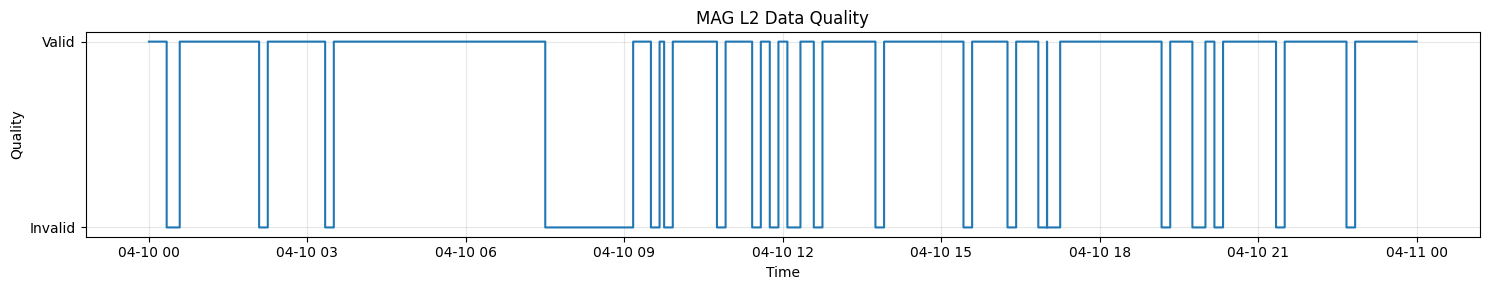

In [13]:
plt.figure(figsize=(15, 3))

plt.step(
    time_utc,
    quality_flags,
    where="post"
)

plt.xlabel("Time")
plt.ylabel("Quality")
plt.yticks([0, 1], ["Invalid", "Valid"])
plt.title("MAG L2 Data Quality")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
valid = quality_flags == 1

magnetic_field = {}

for variable in ["Bx_gse", "By_gse", "Bz_gse"]:
    values = ds[variable].values.astype(float)
    values[~valid] = np.nan
    magnetic_field[variable] = values

In [15]:
for variable, values in magnetic_field.items():
    print(f"\n{variable}")
    print(f"Valid:   {np.count_nonzero(~np.isnan(values))}")
    print(f"Mean:    {np.nanmean(values):.3f} nT")
    print(f"Std:     {np.nanstd(values):.3f} nT")
    print(f"Min:     {np.nanmin(values):.3f} nT")
    print(f"Max:     {np.nanmax(values):.3f} nT")
    print(f"Median:  {np.nanmedian(values):.3f} nT")


Bx_gse
Valid:   6741
Mean:    -6.246 nT
Std:     3.814 nT
Min:     -13.919 nT
Max:     4.234 nT
Median:  -6.824 nT

By_gse
Valid:   6741
Mean:    -0.802 nT
Std:     5.111 nT
Min:     -12.407 nT
Max:     10.016 nT
Median:  -0.314 nT

Bz_gse
Valid:   6741
Mean:    3.055 nT
Std:     3.818 nT
Min:     -4.920 nT
Max:     15.206 nT
Median:  2.610 nT


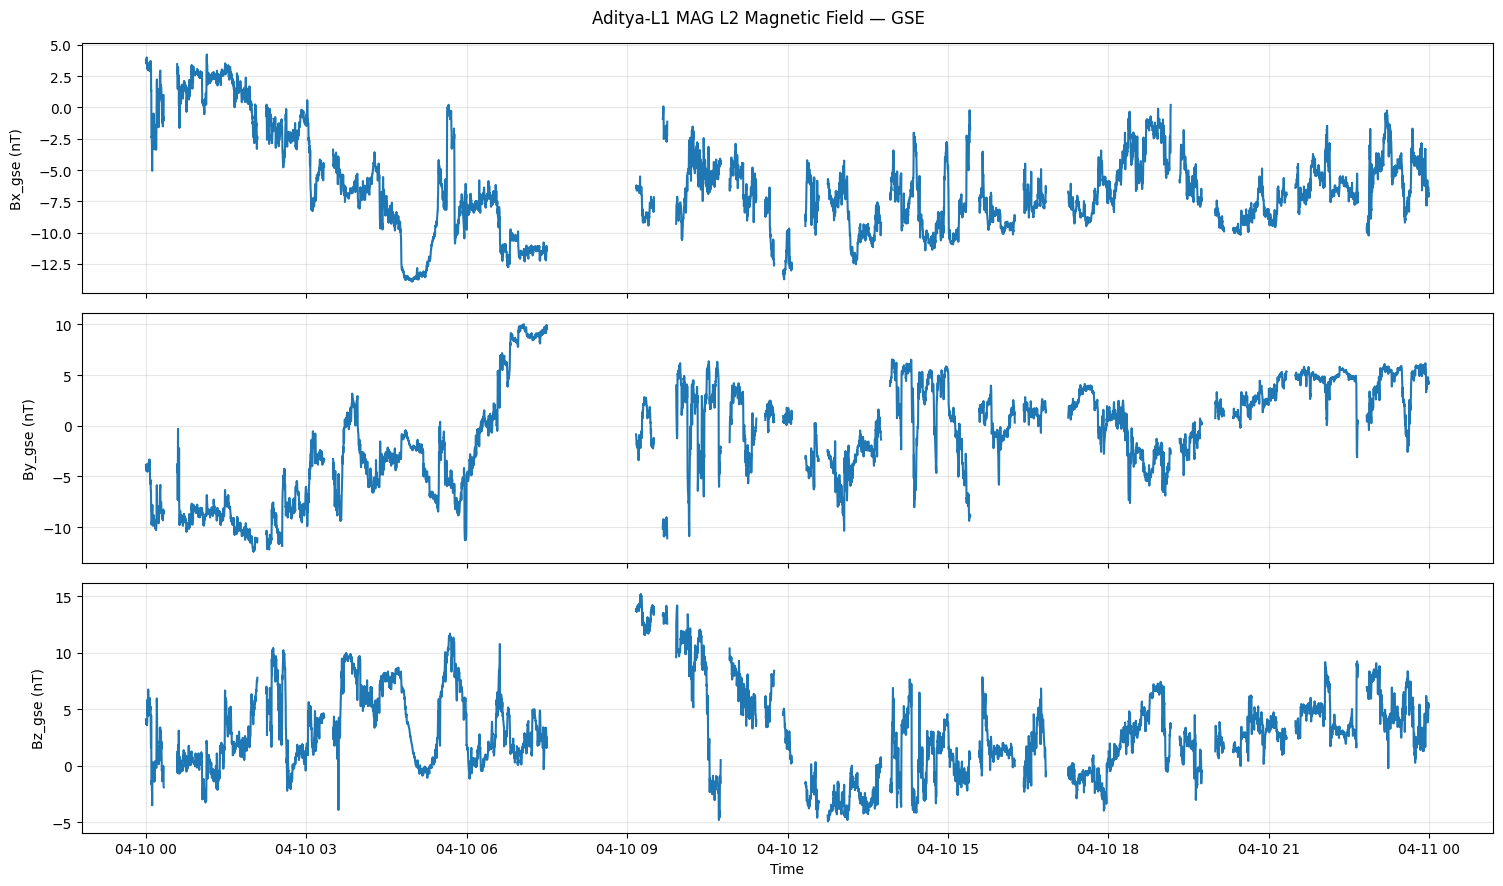

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

for ax, component in zip(
    axes,
    ["Bx_gse", "By_gse", "Bz_gse"]
):
    ax.plot(time_utc, magnetic_field[component])
    ax.set_ylabel(f"{component} (nT)")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
fig.suptitle("Aditya-L1 MAG L2 Magnetic Field — GSE")

plt.tight_layout()
plt.show()

In [17]:
B_magnitude = np.sqrt(
    magnetic_field["Bx_gse"] ** 2
    + magnetic_field["By_gse"] ** 2
    + magnetic_field["Bz_gse"] ** 2
)

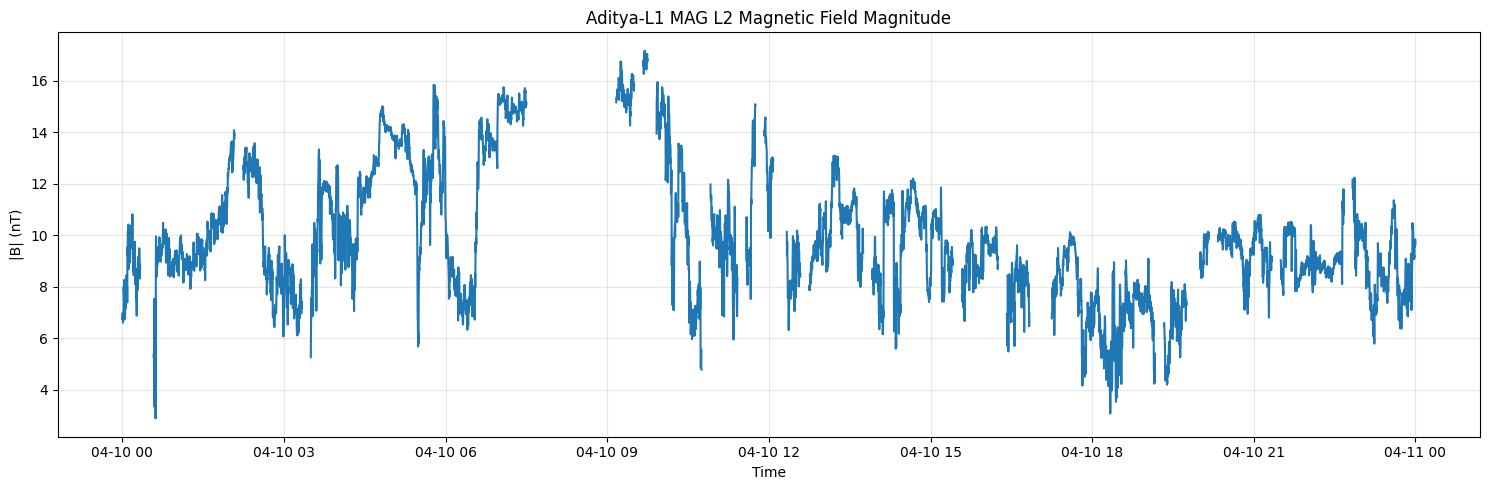

In [18]:
plt.figure(figsize=(15, 5))

plt.plot(time_utc, B_magnitude)

plt.xlabel("Time")
plt.ylabel("|B| (nT)")
plt.title("Aditya-L1 MAG L2 Magnetic Field Magnitude")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
time_utc = pd.to_datetime(ds["time"].values, unit="s", utc=True)

invalid_mask = ds["Quality_flag_10s_data"].values == 0

invalid_times = time_utc[invalid_mask]

print(f"First invalid timestamp: {invalid_times[0]}")
print(f"Last invalid timestamp: {invalid_times[-1]}")
print(f"Invalid duration: {invalid_times[-1] - invalid_times[0]}")

First invalid timestamp: 2026-04-10 00:20:10+00:00
Last invalid timestamp: 2026-04-10 22:49:50+00:00
Invalid duration: 0 days 22:29:40


In [20]:
valid_B = B_magnitude[~np.isnan(B_magnitude)]

print(f"Valid observations: {len(valid_B)}")
print(f"Mean:   {np.mean(valid_B):.3f} nT")
print(f"Std:    {np.std(valid_B):.3f} nT")
print(f"Median: {np.median(valid_B):.3f} nT")
print(f"Min:    {np.min(valid_B):.3f} nT")
print(f"Max:    {np.max(valid_B):.3f} nT")

Valid observations: 6741
Mean:   9.902 nT
Std:    2.490 nT
Median: 9.469 nT
Min:    2.898 nT
Max:    17.170 nT


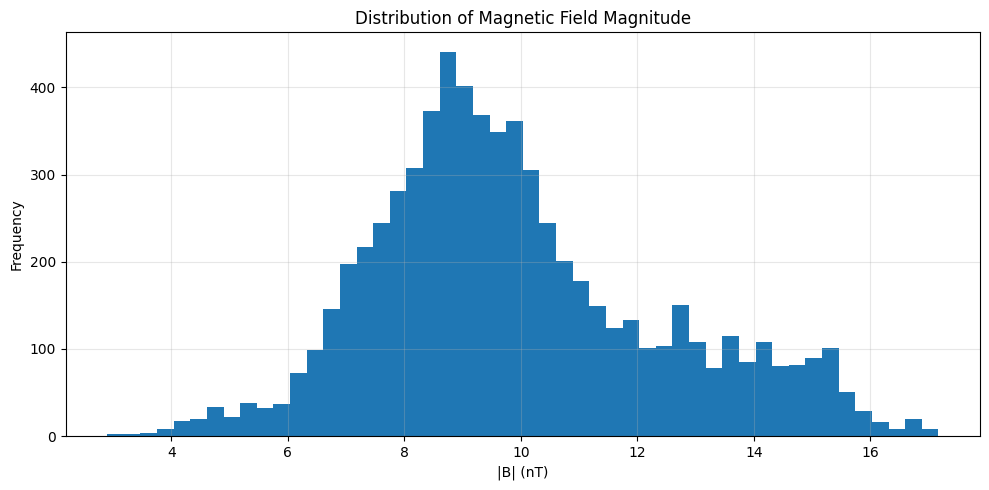

In [21]:
plt.figure(figsize=(10, 5))

plt.hist(valid_B, bins=50)

plt.xlabel("|B| (nT)")
plt.ylabel("Frequency")
plt.title("Distribution of Magnetic Field Magnitude")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()